# NER: reconocer entidades con BERT

Una noticia completa ya no recibe una sola etiqueta: asignamos etiquetas a sus palabras para localizar
**personas (PER), organizaciones (ORG), lugares (LOC) y otras entidades (MISC)**.

| Palabra | Etiqueta | Interpretación |
|---|---|---|
| John | B-PER | Comienza una persona |
| Smith | I-PER | Continúa esa persona |
| visited | O | Fuera de una entidad |
| New | B-LOC | Comienza un lugar |
| York | I-LOC | Continúa ese lugar |

**Hipótesis:** ajustar todo BERT podría mejorar la detección frente a entrenar solo sus dos últimas capas;
mediremos si la diferencia justifica el costo. El ganador no está fijado de antemano.

## 1. Preparar el entorno
Usamos el entorno de AG News más `seqeval==1.2.2`. El repositorio completo debe estar disponible,
incluidos `src/ner_experiment.py` y `src/agnews_experiment.py` (utilidades compartidas).
Consulta `NER_GUIDE.md` para instalación local o en Colab.

In [1]:
from pathlib import Path
import sys, os, json
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "ner_experiment.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Abre el notebook dentro del repositorio completo")
sys.path.insert(0, str(ROOT / "src"))
print("Proyecto:", ROOT)
print("Python:", sys.executable)
# En un entorno nuevo, instalar una vez y reiniciar el kernel:
# %pip install -r {ROOT / "requirements-ner.txt"}

Proyecto: C:\Users\IGNITER\Downloads\bert-adaptation
Python: C:\Users\IGNITER\Documents\ChatGPT\Cosas Escuela 2\.venv-agnews\Scripts\python.exe


## 2. Configuración
- BERT-base-cased conserva mayúsculas, una señal útil para nombres propios.
- CoNLL-2003: particiones oficiales train/validation/test. Se auditan coincidencias textuales entre ellas.
- Ajuste parcial: cabeza + últimas dos capas. Ajuste completo: todos los parámetros.
- Tres épocas, semilla 42, batch efectivo 16, LR cabeza 1e-3 y encoder 2e-5.
- Sin truncar frases; padding dinámico. Solo la primera subpalabra recibe la etiqueta de su palabra.

`SMOKE=True` ejecuta 32/16/16 frases, una época. Sirve para comprobar el código; sus métricas no son entregables.

In [2]:
from datetime import datetime
from dataclasses import asdict
from ner_experiment import Config, run_experiment
import torch
SMOKE = os.environ.get("NER_SMOKE", "0") == "1"
cfg = Config(smoke=SMOKE, epochs=1 if SMOKE else 3)
RUN = ROOT / "runs" / (os.environ.get("NER_RUN_NAME") or
                       (("ner_smoke_" if SMOKE else "ner_") + datetime.now().strftime("%Y%m%d_%H%M%S")))
print(asdict(cfg))
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Salida:", RUN)

C:\Users\IGNITER\Documents\ChatGPT\Cosas Escuela 2\.venv-agnews\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'seed': 42, 'epochs': 3, 'micro_batch': 8, 'accumulation': 2, 'top_layers': 2, 'head_lr': 0.001, 'backbone_lr': 2e-05, 'weight_decay': 0.01, 'model_id': 'google-bert/bert-base-cased', 'dataset_id': 'lhoestq/conll2003', 'model_revision': None, 'dataset_revision': None, 'smoke': False}
GPU: NVIDIA GeForce RTX 4060 Ti
Salida: C:\Users\IGNITER\Downloads\bert-adaptation\runs\ner_verified


## 3. Alinear, entrenar y elegir
Antes del entrenamiento, la siguiente celda imprime un batch de subtokens y etiquetas.
Se comprueba que cada palabra tenga exactamente una etiqueta y que especiales, continuaciones y padding tengan `-100`.
La auditoría completa queda en `alignment_check.csv`.

La pérdida se promedia por palabras supervisadas. La **métrica principal** es F1 micro de entidades en modo estricto IOB2:
tipo y límites completos deben coincidir. Detectar solo “New” no acierta la entidad “New York”.
Accuracy por palabra es secundaria: acertar muchas `O` no demuestra que se detecten bien las entidades.

Se guarda la mejor época por validación de cada alternativa y después se selecciona el método.
Solo entonces se evalúa test. La parte congelada mantiene dropout desactivado y se verifican sus pesos por hash.

In [3]:
comparison = run_experiment(cfg, RUN)
display(comparison)

Align train:   0%|          | 0/14041 [00:00<?, ? examples/s]

Align train:   5%|▍         | 689/14041 [00:00<00:01, 6689.62 examples/s]

Align train:  11%|█         | 1561/14041 [00:00<00:02, 5907.59 examples/s]

Align train:  15%|█▌        | 2166/14041 [00:00<00:02, 5916.80 examples/s]

Align train:  20%|█▉        | 2781/14041 [00:00<00:01, 5977.97 examples/s]

...

full_finetuning: epoch 3, batch 1400/1756


full_finetuning: epoch 3, batch 1600/1756


full_finetuning {"epoch": 3, "train_loss": 0.0110191266787118, "train_seconds": 147.77985939997598, "validation_seconds": 7.421826400008285, "val_loss": 0.037985923766525015, "val_precision": 0.9477310924369748, "val_recall": 0.9490070683271625, "val_f1": 0.9483686511940801, "val_token_accuracy": 0.9909076749347767, "val_conlleval_f1": 0.9456312306274608, "val_invalid_predicted_i_transitions": 45}


COMPLETE: C:\Users\IGNITER\Downloads\bert-adaptation\runs\ner_verified winner: full_finetuning


,method,best_epoch,best_val_f1,trainable_parameters,total_parameters,frozen_parameters_verified,train_seconds,peak_allocated_gpu_bytes,test_loss,test_precision,test_recall,test_f1,test_token_accuracy,test_conlleval_f1,test_invalid_predicted_i_transitions,selected
0,partial_finetuning,3,0.920415,14182665,107726601,True,145.792294,862582784,0.091742,0.890973,0.891289,0.891131,0.978400,0.879617,182,False
1,full_finetuning,3,0.948369,107726601,107726601,False,441.893810,2862062080,0.095744,0.911310,0.918732,0.915006,0.982944,0.910398,64,True


## 4. Interpretar las curvas
Precisión: de las entidades predichas, cuántas fueron correctas.
Recall: de las entidades reales, cuántas encontramos. F1 combina ambas.
Una sola semilla no permite afirmar significancia estadística: diferencias pequeñas pueden depender del azar.

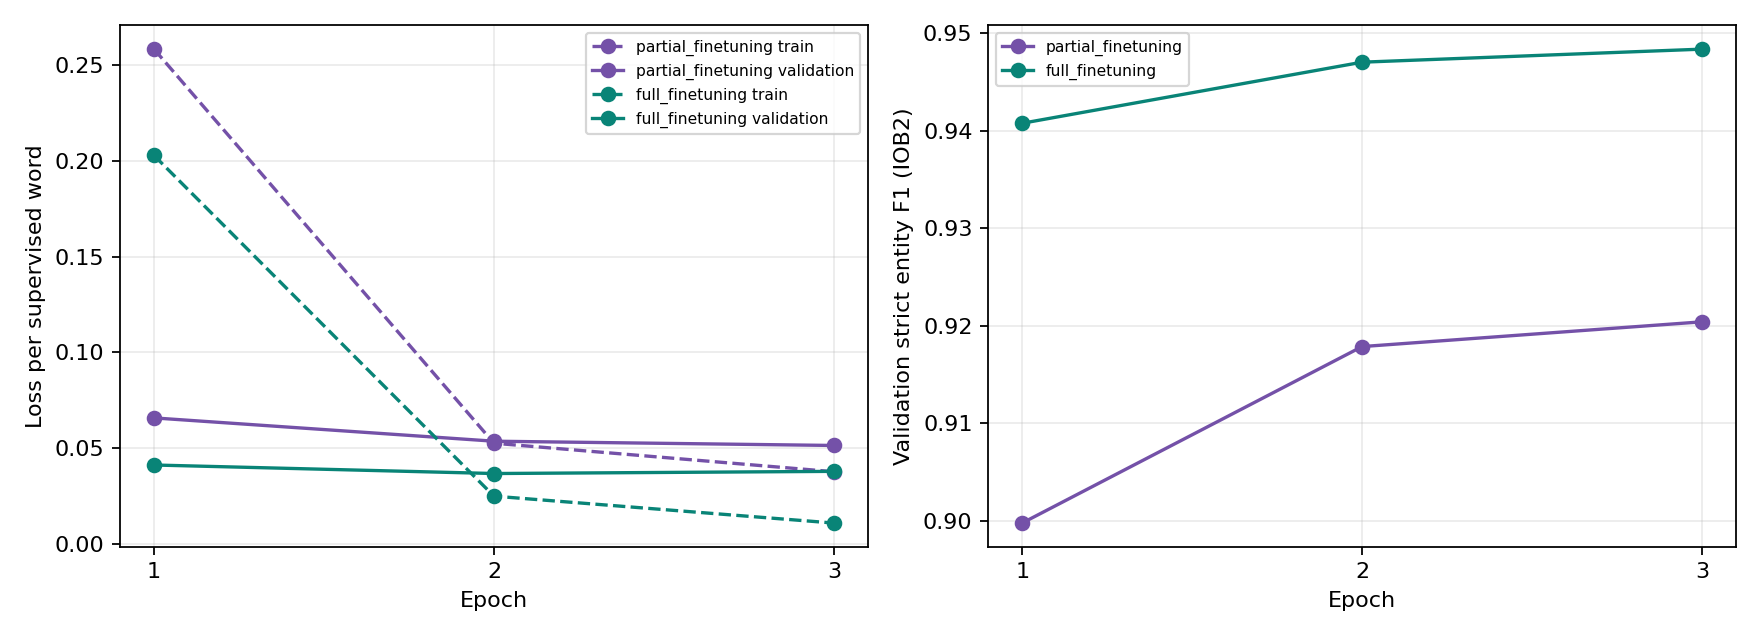

# NER: resultados medidos

Comparación final; una semilla por configuración.

Particiones oficiales: {'train': 14041, 'validation': 3250, 'test': 3453}. Sin truncamiento; máximos de subtokens: {'train': 173, 'validation': 151, 'test': 148}.
Frases exactas compartidas entre particiones (conservadas para mantener el benchmark): {'train/validation': 129, 'train/test': 78, 'validation/test': 25}.
Selección: F1 micro de entidades, seqeval strict IOB2. La entidad debe coincidir en tipo, inicio y fin.

| Método | Época | F1 validación | Precisión prueba | Recall prueba | F1 prueba | Entrenamiento (s) |
|---|---:|---:|---:|---:|---:|---:|
| partial_finetuning | 3 | 0.9204 | 0.8910 | 0.8913 | 0.8911 | 145.8 |
| full_finetuning | 3 | 0.9484 | 0.9113 | 0.9187 | 0.9150 | 441.9 |

Ganador por validación: **full_finetuning**. Prueba se evaluó después de guardar la selección.
Los tiempos excluyen validación y guardado; ambos métodos ejecutan el cuerpo de BERT en cada lote.
La pérdida se promedia por palabras supervisadas, no por frases ni subtokens ignorados.
Una semilla no establece superioridad estadística; diferencias pequeñas pueden depender del azar.
No se ajustaron hiperparámetros con prueba. Las etiquetas O no dominan la métrica principal de entidades.

## Errores: partial_finetuning

```json
{
  "gold_entities": 5648,
  "predicted_entities": 5650,
  "correct_entities": 5034,
  "false_positive_entities": 616,
  "wrong_type_exact_boundary": 240,
  "missed_entity": 160,
  "overlapping_wrong_boundary": 214
}
```

Tipos incorrectos, límites incorrectos y entidades omitidas son categorías excluyentes de errores sobre entidades reales. Falsos positivos se cuentan aparte.

## Errores: full_finetuning

```json
{
  "gold_entities": 5648,
  "predicted_entities": 5694,
  "correct_entities": 5189,
  "false_positive_entities": 505,
  "wrong_type_exact_boundary": 220,
  "missed_entity": 82,
  "overlapping_wrong_boundary": 157
}
```

Tipos incorrectos, límites incorrectos y entidades omitidas son categorías excluyentes de errores sobre entidades reales. Falsos positivos se cuentan aparte.

Evidencia: data_manifest.json, alignment_check.csv, historiales, selection.json, predicciones por palabra, métricas por tipo y ejemplos de error.
BERT-base-cased, precisión bf16 cuando la GPU lo admite, semilla 42 y dos grupos de LR (cabeza 1e-3, encoder 2e-5).
Fuentes: https://huggingface.co/datasets/lhoestq/conll2003 ; https://github.com/chakki-works/seqeval ; https://arxiv.org/abs/1810.04805
POS y QA siguen pendientes. El reporte PDF anterior aún no fue actualizado. Modelo exportado localmente, no publicado.


Ejemplo del batch de alineación:


,batch_row,source_row,position,subtoken,word,label_id,label
0,0,0,0,[CLS],NaN,-100,IGNORE
1,0,0,1,EU,EU,3,B-ORG
2,0,0,2,rejects,rejects,0,O
3,0,0,3,German,German,7,B-MISC
4,0,0,4,call,call,0,O
5,0,0,5,to,to,0,O
6,0,0,6,boycott,boycott,0,O
7,0,0,7,British,British,7,B-MISC
8,0,0,8,la,lamb,0,O
9,0,0,9,##mb,lamb,-100,IGNORE


In [4]:
import pandas as pd
from IPython.display import Image, Markdown, display
display(Image(filename=str(RUN / "learning_curves.png")))
display(Markdown((RUN / "RESULTS.md").read_text(encoding="utf-8")))
print("Ejemplo del batch de alineación:")
display(pd.read_csv(RUN / "alignment_check.csv").head(35))

## 5. Entender errores concretos
Revisamos tipos incorrectos, límites incorrectos y entidades omitidas. Los falsos positivos se cuentan aparte.
Estas observaciones describen el resultado final; no usamos test para retocar el entrenamiento.
`per_type` muestra si un tipo de entidad presenta más dificultad que otros.

In [5]:
for method in comparison.method:
    print(method)
    scores = json.loads((RUN / method / "test_metrics.json").read_text(encoding="utf-8"))
    display(pd.DataFrame(scores["per_type"]).T)
    errors = json.loads((RUN / method / "error_analysis.json").read_text(encoding="utf-8"))
    print(errors["counts"])
    display(pd.DataFrame(errors["examples"][:5]))

partial_finetuning


,precision,recall,f1-score,support
LOC,0.900906,0.893885,0.897382,1668.0
MISC,0.822086,0.763533,0.791728,702.0
ORG,0.853518,0.891030,0.871870,1661.0
PER,0.949037,0.944341,0.946683,1617.0
micro avg,0.890973,0.891289,0.891131,5648.0
macro avg,0.881387,0.873197,0.876916,5648.0
weighted avg,0.890953,0.891289,0.890862,5648.0


{'gold_entities': 5648, 'predicted_entities': 5650, 'correct_entities': 5034, 'false_positive_entities': 616, 'wrong_type_exact_boundary': 240, 'missed_entity': 160, 'overlapping_wrong_boundary': 214}


,source_row,text,missed_or_wrong,extra_or_wrong
0,0,"SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRI...","[{'type': 'LOC', 'start_word': 2, 'end_word_ex...","[{'type': 'PER', 'start_word': 2, 'end_word_ex..."
1,12,Defender Hassan Abbas rose to intercept a long...,"[{'type': 'PER', 'start_word': 27, 'end_word_e...","[{'type': 'ORG', 'start_word': 27, 'end_word_e..."
2,22,RUGBY UNION - CUTTITTA BACK FOR ITALY AFTER A ...,"[{'type': 'LOC', 'start_word': 6, 'end_word_ex...","[{'type': 'MISC', 'start_word': 3, 'end_word_e..."
3,28,Cuttitta announced his retirement after the 19...,"[{'type': 'MISC', 'start_word': 6, 'end_word_e...","[{'type': 'MISC', 'start_word': 7, 'end_word_e..."
4,34,SOCCER - LATE GOALS GIVE JAPAN WIN OVER SYRIA .,"[{'type': 'LOC', 'start_word': 5, 'end_word_ex...","[{'type': 'PER', 'start_word': 5, 'end_word_ex..."


full_finetuning


,precision,recall,f1-score,support
LOC,0.932611,0.929257,0.930931,1668.0
MISC,0.815714,0.813390,0.814551,702.0
ORG,0.883178,0.910295,0.896531,1661.0
PER,0.960494,0.962276,0.961384,1617.0
micro avg,0.911310,0.918732,0.915006,5648.0
macro avg,0.897999,0.903804,0.900849,5648.0
weighted avg,0.911527,0.918732,0.915068,5648.0


{'gold_entities': 5648, 'predicted_entities': 5694, 'correct_entities': 5189, 'false_positive_entities': 505, 'wrong_type_exact_boundary': 220, 'missed_entity': 82, 'overlapping_wrong_boundary': 157}


,source_row,text,missed_or_wrong,extra_or_wrong
0,0,"SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRI...","[{'type': 'LOC', 'start_word': 2, 'end_word_ex...","[{'type': 'ORG', 'start_word': 7, 'end_word_ex..."
1,12,Defender Hassan Abbas rose to intercept a long...,"[{'type': 'PER', 'start_word': 27, 'end_word_e...","[{'type': 'ORG', 'start_word': 27, 'end_word_e..."
2,15,Bitar pulled off fine saves whenever they did .,"[{'type': 'PER', 'start_word': 0, 'end_word_ex...","[{'type': 'ORG', 'start_word': 0, 'end_word_ex..."
3,22,RUGBY UNION - CUTTITTA BACK FOR ITALY AFTER A ...,"[{'type': 'LOC', 'start_word': 6, 'end_word_ex...","[{'type': 'ORG', 'start_word': 3, 'end_word_ex..."
4,28,Cuttitta announced his retirement after the 19...,"[{'type': 'MISC', 'start_word': 6, 'end_word_e...","[{'type': 'MISC', 'start_word': 7, 'end_word_e..."


## 6. Probar el modelo exportado
La ejecución final exporta y recarga el ganador, con su tokenizer y model card.
La inferencia conserva la misma regla de primera subpalabra usada en la evaluación.
Este ejemplo comprueba funcionamiento; no reemplaza las métricas de prueba.
La publicación en Hugging Face queda para la etapa de publicación.

In [6]:
if not SMOKE:
    example = json.loads((RUN / "inference_example.json").read_text(encoding="utf-8"))
    display(pd.DataFrame({"palabra": example["words"], "etiqueta": example["tags"]}))
    print("Modelo:", RUN / "delivered_model_ner")
else:
    print("Smoke completado. Falta la ejecución completa para obtener resultados entregables.")

,palabra,etiqueta
0,John,B-PER
1,Smith,I-PER
2,works,O
3,for,O
4,Microsoft,B-ORG
5,in,O
6,New,B-LOC
7,York,I-LOC
8,.,O


Modelo: C:\Users\IGNITER\Downloads\bert-adaptation\runs\ner_verified\delivered_model_ner
